# Unsupervised Learning

Unsupervised learning analyzes data without labeled outcomes. Instead of predicting a known target, the goal is to discover hidden structure, recurring patterns, or natural groupings in the data.

From a business analytics perspective, unsupervised learning is especially useful when an organization has a large amount of data but no predefined labels. Common use cases include customer segmentation, anomaly detection, product grouping, and exploratory pattern discovery.

In this notebook, we consider a customer segmentation example using the Mall Customer Segmentation dataset from Kaggle.  
Data link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


### Clustering

Clustering is an unsupervised learning technique used to group similar observations together. The objective is to create groups in which observations within the same cluster are more alike than observations in different clusters.

A helpful business question is:

> “Are there natural segments in the data that we can understand and act on?”

Typical business applications include:
- customer segmentation,
- anomaly detection,
- market profiling,
- product categorization.

Clustering is valuable because it turns raw data into a more interpretable structure that can support strategy, targeting, and resource allocation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
### help function to load the dataset. 
def loadDataSet():
    a = []
    f = open("../../data/B.txt",'r')
    lines = f.readlines()   #make lines a list, has index inside already
    f.close()
    for line in lines:
        b = ['', '']
        b[0],b[1] = line.split()
        a.append(b)
    dataSet = np.array(a, dtype=float)   
    return dataSet

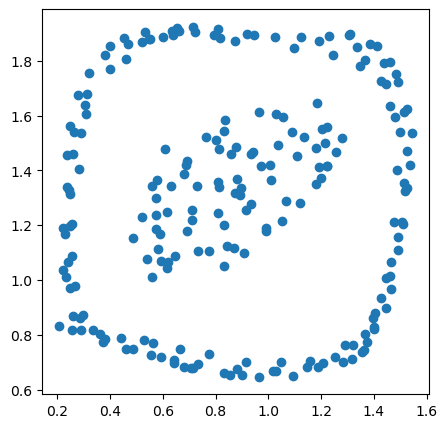

In [2]:
X = loadDataSet()
plt.figure(figsize = (5, 5))  
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [3]:
n, d = X.shape
n, d

(218, 2)

### Quantifying Distance in Machine Learning

In machine learning, measuring similarity or dissimilarity between data points is essential for tasks such as clustering, nearest-neighbor methods, and anomaly detection.

From a business perspective, the distance metric defines what we mean by “similar.” Different definitions of similarity can lead to different segmentation results and, therefore, different managerial actions.

#### 1. Euclidean Distance
- Measures the straight-line (L2-norm) distance between two points
- Most widely used distance metric

$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$

#### 2. Manhattan Distance
- Measures distance along axes (L1-norm), like navigating a city grid
- Often more robust to outliers than Euclidean distance

$
d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
$

#### 3. Minkowski Distance
- A generalized distance metric that includes Euclidean and Manhattan as special cases
- Controlled by parameter \( p \)


$
d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}
$


Special cases:
- \( p = 1 \) → Manhattan Distance
- \( p = 2 \) → Euclidean Distance


In [3]:
# Euclidean distance
def euclidean_distance(x1, x2):
    # np.sum((x1 - x2)**2 = (x11 - x21)**2 + (x12 - x22)**2
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    return np.sum(abs((x1 - x2)))

### K-Means Clustering

##### General process

K-means is one of the most widely used clustering algorithms because it is intuitive and easy to visualize. In a business context, it is commonly used for segmentation.

General steps:

1. Select the number of clusters \(k\)
2. Initialize \(k\) centroids randomly
3. Assign each observation to its nearest centroid
4. Update each centroid to the center of its assigned observations
5. Repeat until the assignments stabilize or a maximum number of iterations is reached

The algorithm aims to minimize the within-cluster sum of squares, meaning observations within a cluster should be as close as possible to their centroid.

Business interpretation:
- each cluster can represent a segment,
- each centroid can be viewed as a typical profile for that segment,
- and the final grouping can inform targeting, pricing, communication, or service strategies.

K-means is simple and useful, but it is sensitive to the initial centroids and may converge to a local minimum. For that reason, it is good practice to run it multiple times and compare results.

KMean: https://www.youtube.com/watch?v=GZj6ikx8PAc


In [4]:
# K-means clustering
def kmeans_clustering(X, k, max_iters = 200):
    n, d = X.shape
    centers = X[np.random.choice(n, k, replace=False)] # randomly pick k data instance in X as the centriods. 
    # you can also randomly assign two points to the decision space. 
    print(centers)
    labels = np.zeros(n)
    
    for iter in range(max_iters):
        # Assign each data point to the nearest center
        for i in range(n):
            distances = [euclidean_distance(X[i], center) for center in centers]
            labels[i] = np.argmin(distances)
        # print("Current Iteration Number: ", iter)
        # print("Distance in current iteration: ", distances)
        # Update centers
        for j in range(k):
            centers[j] = np.mean(X[labels == j], axis=0)
    
    return labels, centers

[[0.5919 0.7208]
 [1.4661 0.9664]]
[1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1.
 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1.
 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.
 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 0. 0.]


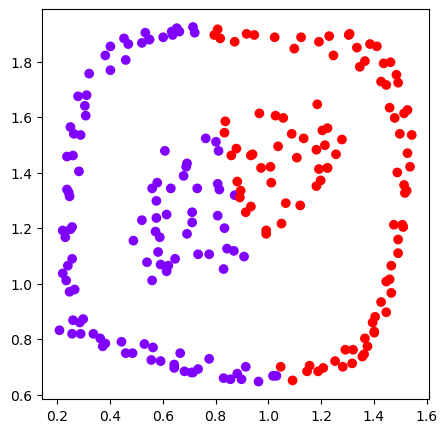

In [10]:
# Fit KMeans and get the predictions

# seed = 9 # Control the random behavior of KMean
# np.random.seed(seed)

label_pred, centroid = kmeans_clustering(X, k = 2)

print(label_pred)

plt.figure(figsize = (5, 5))  
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X[:, 0], X[:, 1], c = label_pred, cmap ='rainbow')
plt.show()

[[0.2823 1.4044]
 [0.8339 1.5436]]
[1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1.
 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1.
 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0.
 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1.
 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 0. 0.]


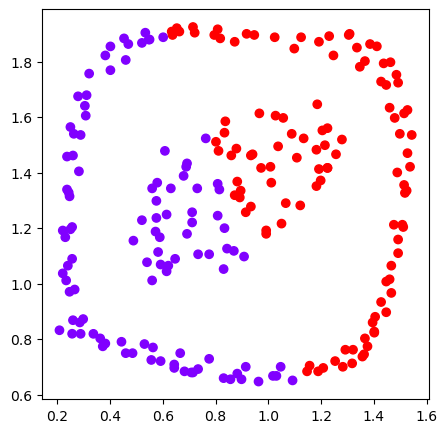

In [7]:
# Fit KMeans and get the predictions

# seed = 9 # Control the random behavior of KMean
# np.random.seed(seed)

label_pred, centroid = kmeans_clustering(X, k = 2)

print(label_pred)

plt.figure(figsize = (5, 5))  
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X[:, 0], X[:, 1], c = label_pred, cmap ='rainbow')
plt.show()

[[0.7339 1.1056]
 [1.1081 1.4535]]
[1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0.
 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.
 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0.
 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1.
 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 1. 0.]


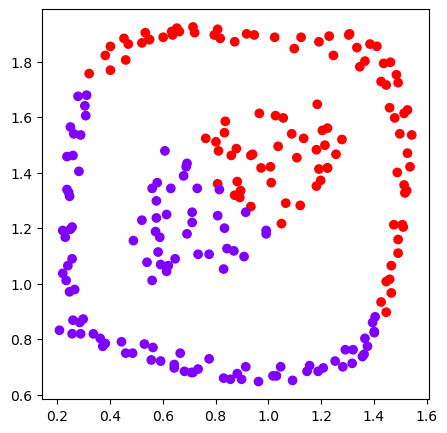

In [8]:
# Fit KMeans and get the predictions

seed = 9 # Control the random behavior of KMean
np.random.seed(seed)

label_pred, centroid = kmeans_clustering(X, k = 2)

print(label_pred)

plt.figure(figsize = (5, 5))  
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X[:, 0], X[:, 1], c = label_pred, cmap ='rainbow')
plt.show()

[[0.7339 1.1056]
 [1.1081 1.4535]]
[1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0.
 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.
 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0.
 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1.
 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 1. 0.]


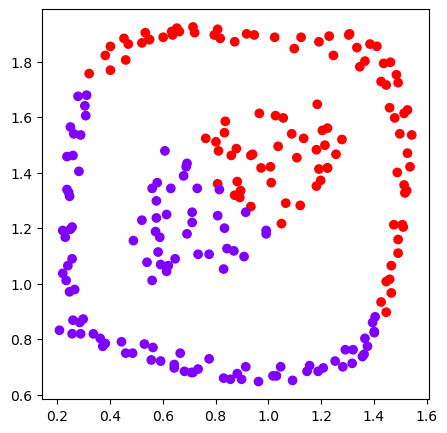

In [9]:
# Fit KMeans and get the predictions

seed = 9 # Control the random behavior of KMean
np.random.seed(seed)

label_pred, centroid = kmeans_clustering(X, k = 2)

print(label_pred)

plt.figure(figsize = (5, 5))  
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X[:, 0], X[:, 1], c = label_pred, cmap ='rainbow')
plt.show()

### Business Insight

When choosing K, the real question is: how many segments can the organization realistically recognize, understand, and act on? A slightly less “optimal” K may be better if it produces clearer and more usable segments.


## Choosing the Number of Clusters for K-Means

In supervised learning, performance can often be judged against known labels. In clustering, there is no labeled answer key, so selecting the number of clusters requires both analytical evidence and business judgment.

A common criterion in K-means is the sum of squared distances between observations and their assigned centroids:

$$\Large J(C) = \sum_{k=1}^K\sum_{i~\in~C_k} ||x_i - \mu_k|| \rightarrow \min\limits_C,$$

where $C$ – is a set of clusters with power $K$, $\mu_k$ is a centroid of a cluster $C_k$.

This criterion is useful, but it creates a challenge: if every observation becomes its own cluster, the objective becomes extremely small. That would not be useful from a business perspective.

So in practice, we often look for an “elbow,” a point after which adding more clusters yields only limited improvement. The best value of K is not always the one that minimizes the objective the most; it is often the one that creates segments that are both distinct and actionable.


Current Iteration Number:  0
Distance in current iteration:  [0.4561160597918034]
Current Iteration Number:  1
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  2
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  3
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  4
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  5
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  6
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  7
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  8
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  9
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  10
Distance in current iteration:  [0.3277544475433362]
Current Iteration Number:  11
Distance in current iteration:  [0.3277544475433362]
Current Iterat

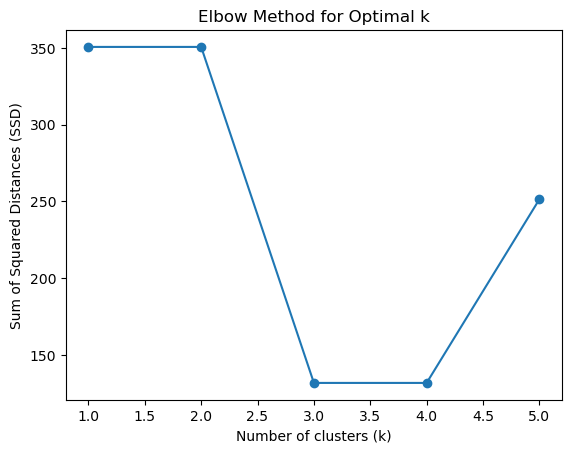

In [4]:
# Calculate the sum of squared distances (SSD) for a range of k values
def calculate_ssd(X, k_range):
    ssd = []
    for k in k_range:
        centers, labels = kmeans_clustering(X, k)
        ssd.append(sum(np.min(np.array([[euclidean_distance(X[i], centers[j]) for j in range(k)] for i in range(len(X))]), axis = 1)))
    return ssd

# Range of k values
k_range = range(1, 6)

# Calculate SSD for each k value
ssd = calculate_ssd(X, k_range)

# Plot SSD vs. k
print(ssd)
plt.plot(k_range, ssd, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.title('Elbow Method for Optimal k')
plt.show()

### Interpreting the SSD Result

The lowest SSD may suggest 3 or 4 clusters, but that does not automatically mean it is the best choice for the problem.

Business understanding still matters. A useful segmentation should not only fit the data well, but also produce groups that are interpretable and practical for decision-making. In other words, the statistically best K is not always the most useful K.


### Agglomerative Clustering

Agglomerative clustering is a hierarchical clustering technique that begins with each observation as its own cluster and then repeatedly merges the closest clusters.

General process:

1. Start with each data point as a separate cluster
2. Find the two closest clusters
3. Merge them
4. Recompute distances between clusters
5. Continue until the desired number of clusters remains

Compared with K-means, hierarchical clustering does not depend on initial centroids. It is often useful for exploratory analysis because it helps us understand how groups are related to one another.

Business value:
- reveals nested relationships among observations,
- supports exploratory segmentation,
- can help analysts explain how broader groups split into finer subgroups.

Different linkage rules can still produce different results, so interpretation remains important.

Agglomerative: https://www.youtube.com/watch?v=8QCBl-xdeZI


In [17]:
# Perform agglomerative clustering
def agglomerative_clustering(X, k):
    n = X.shape[0]
    clusters = [[i] for i in range(n)]
    while len(clusters) > k: # stopping criteria
        min_dist = np.inf
        merge_indices = None
        
        # Find closest clusters to merge
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                cluster1 = clusters[i]
                cluster2 = clusters[j]
                
                # Calculate distance between clusters (single-linkage)
                dist = np.min([euclidean_distance(X[p1], X[p2]) for p1 in cluster1 for p2 in cluster2])
                # Calculate distance between clusters (complete-linkage)
                # dist = np.max([euclidean_distance(X[p1], X[p2]) for p1 in cluster1 for p2 in cluster2])
                # Calculate distance between clusters (average linkage)
                # dist = np.mean([euclidean_distance(X[p1], X[p2]) for p1 in cluster1 for p2 in cluster2])
                
                if dist < min_dist:
                    min_dist = dist
                    merge_indices = (i, j)
        
        # Merge closest clusters
        i, j = merge_indices
        clusters[i].extend(clusters[j])
        del clusters[j]
    
    return clusters

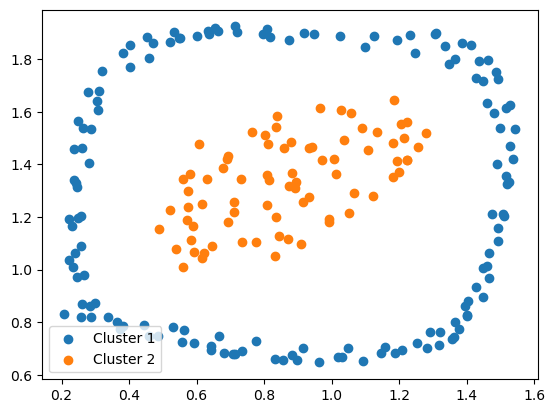

In [18]:
# Single linkage
# Run agglomerative clustering
k = 2  # Number of clusters
clusters = agglomerative_clustering(X, k)

# Plot clusters
for i, cluster in enumerate(clusters):
    points = X[cluster]
    plt.scatter(points[:, 0], points[:, 1], label=f'Cluster {i+1}')

plt.legend()
plt.show()

### Any conclusion?

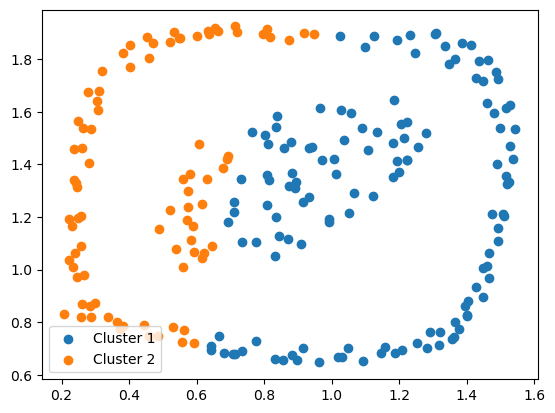

In [16]:
# Complete linkage
# Run agglomerative clustering
k = 2  # Number of clusters
clusters = agglomerative_clustering(X, k)

# Plot clusters
for i, cluster in enumerate(clusters):
    points = X[cluster]
    plt.scatter(points[:, 0], points[:, 1], label=f'Cluster {i+1}')

plt.legend()
plt.show()

### Any conclusion?

### Using `sklearn` Clustering Tools for a Customer Segmentation Problem

After learning the core ideas manually, we now use `sklearn` implementations to perform clustering more efficiently. This mirrors real business analytics workflows, where analysts need methods that are reliable, scalable, and easy to reproduce.


In [6]:
mallData = pd.read_csv('../../data/Mall_Customers.csv')
mallData

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [7]:
mallData['Gender_num'] = mallData['Gender'].astype('category').cat.codes
mallData

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_num
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,1


In [8]:
mallData.drop(['CustomerID', 'Gender'], axis = 1, inplace = True)
mallData

,Age,Annual Income (k$),Spending Score (1-100),Gender_num
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0
...,...,...,...,...
195,35,120,79,0
196,45,126,28,0
197,32,126,74,1
198,32,137,18,1


In [9]:
mallDataCleaned = mallData.to_numpy()
mallDataCleaned

array([[ 19,  15,  39,   1],
       [ 21,  15,  81,   1],
       [ 20,  16,   6,   0],
       [ 23,  16,  77,   0],
       [ 31,  17,  40,   0],
       [ 22,  17,  76,   0],
       [ 35,  18,   6,   0],
       [ 23,  18,  94,   0],
       [ 64,  19,   3,   1],
       [ 30,  19,  72,   0],
       [ 67,  19,  14,   1],
       [ 35,  19,  99,   0],
       [ 58,  20,  15,   0],
       [ 24,  20,  77,   0],
       [ 37,  20,  13,   1],
       [ 22,  20,  79,   1],
       [ 35,  21,  35,   0],
       [ 20,  21,  66,   1],
       [ 52,  23,  29,   1],
       [ 35,  23,  98,   0],
       [ 35,  24,  35,   1],
       [ 25,  24,  73,   1],
       [ 46,  25,   5,   0],
       [ 31,  25,  73,   1],
       [ 54,  28,  14,   0],
       [ 29,  28,  82,   1],
       [ 45,  28,  32,   0],
       [ 35,  28,  61,   1],
       [ 40,  29,  31,   0],
       [ 23,  29,  87,   0],
       [ 60,  30,   4,   1],
       [ 21,  30,  73,   0],
       [ 53,  33,   4,   1],
       [ 18,  33,  92,   1],
       [ 49,  

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

# mute the warning message. 
import warnings
warnings.filterwarnings('ignore')

KmeanCluster = KMeans(n_clusters = 2)  
KmeanCluster.fit_predict(mallDataCleaned)
print(KmeanCluster.labels_)

[0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0
 0 1 0 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0
 1 0 1 1 1 0 1 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


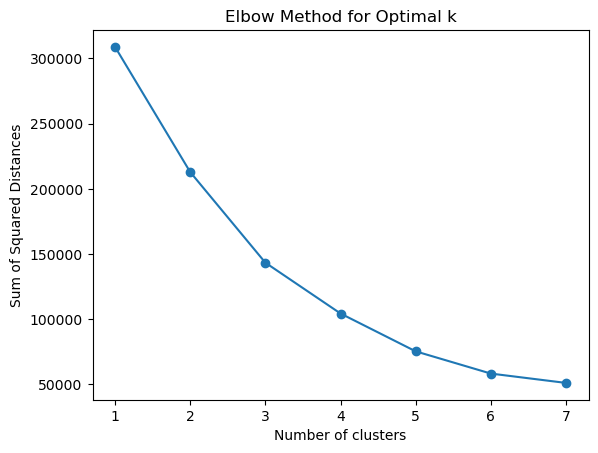

In [11]:
ssd = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(mallDataCleaned)
    ssd.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 8), ssd, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.show()

In [12]:
AggCluster = AgglomerativeClustering(n_clusters = 2, linkage = 'complete')   
AggCluster.fit_predict(mallDataCleaned)
print(AggCluster.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Business Takeaway

In segmentation problems, model quality should be evaluated from two angles:

1. **Analytical quality** — metrics such as SSD or silhouette score  
2. **Managerial usefulness** — whether the resulting groups support targeting, strategy, and communication


In [13]:
from sklearn.metrics import silhouette_score

linkage_methods = ['ward', 'complete', 'average', 'single']
for linkage in linkage_methods:
    clusters = AgglomerativeClustering(n_clusters = 2, linkage = linkage)
    cluster_labels = clusters.fit_predict(mallDataCleaned)
    print(cluster_labels)
    silhouette_avg = silhouette_score(mallDataCleaned, cluster_labels)
    print(f"Silhouette score for {linkage} linkage: {silhouette_avg}")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Silhouette score for ward linkage: 0.29916602844367
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Silhouette score for complete linkage: 0.29916602844367
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 

The silhouette score can be used to compare different linkage methods such as `ward`, `complete`, `average`, and `single`. A higher silhouette score generally indicates stronger cluster separation and cohesion.

From a business point of view, however, the final choice should still consider interpretability. The best clustering solution is not only the one with a better score, but the one that creates segments the organization can meaningfully understand and use.
